
# E-COMMERCE PRODUCT RECOMMENDATION SYSTEM

This system enhances user experience by recommending products that match individual preferences. In addition, it plays an important role in increasing revenue and improving business performance for companies. Studying this topic also provides an opportunity to apply advanced Artificial Intelligence (AI) and Machine Learning techniques in real-world applications. Product recommendation systems have become an essential trend in the rapidly growing e-commerce industry. Finally, this project contributes to the development of sustainable technological solutions and the optimization of the online shopping process.

## What is a Product Recommendation System for E-Commerce Businesses?

A product recommendation system is a software tool that provides personalized product or content suggestions to users based on their behaviors, preferences, and interests.

These systems are highly valuable in e-commerce because they help convert browsers into buyers, increase average order value, and improve customer loyalty by delivering tailored shopping experiences.

There are three main types of recommendation systems:

• Content-Based Recommendation System:
This type of recommendation system analyzes various product attributes such as product name, brand, price, description, and features. It takes a product as input and recommends other products that are similar based on these characteristics.

• User-Based Recommendation System:
Also known as Collaborative Filtering, this approach considers user demographics, activities, preferences, and behaviors. If User A and User B have similar profiles (e.g., age, interests, and activities), and User A likes or interacts with a particular product, the system may recommend that product to User B, and vice versa.

• Popularity-Based Recommendation System:
This system tracks product views, likes, purchases, and other interaction metrics. It then recommends the most popular products by analyzing these indicators, making it particularly useful for new users who have little or no interaction history.

By recommending relevant products, recommendation systems can personalize the user experience, increase user engagement and retention, and ultimately drive higher sales and business growth.

## Building and Implementing the Recommendation Model

### Importing libraries:

In [1]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)

In [17]:
import pandas as pd
import warnings

warnings.filterwarnings("ignore")


# ==============================
# PREPROCESSING
# ==============================

from src.preprocessing import (
    clean_data
)


# ==============================
# EDA
# ==============================

from src.eda import (
    plot_missing_values,
    plot_rating_distribution,
    plot_price_distribution,
    plot_top_departments,
    plot_top_brands,
    plot_price_vs_rating,
    plot_popular_products_by_department
)


# ==============================
# FEATURE ENGINEERING
# ==============================

from src.feature_engineering import (
    create_combined_features,
    create_similarity_matrix,
    create_indices
)


# ==============================
# POPULARITY MODEL
# ==============================

from src.popularity_model import (
    get_popular_products,
    evaluate_popularity
)


# ==============================
# CONTENT-BASED MODEL
# ==============================

from src.content_based_model import (
    recommend_products,
    precision_at_k
)


# ==============================
# COLLABORATIVE FILTERING
# ==============================

from src.collaborative_model import (
    simulate_user_interactions,
    create_user_item_matrix,
    train_knn_model,
    find_similar_users,
    evaluate_collaborative
)


# ==============================
# HYBRID MODEL
# ==============================

from src.hybrid_model import (
    hybrid_recommendation
)

### Import the Dataset:


The dataset used in this project is based on publicly available Amazon product data collected in 2020.

https://brightdata.com/cp/datasets/browse/gd_l7q7dkf244hwjntr0?id=hl_67a497d9&tab=sam

In [5]:
df = pd.read_csv("../data/amazon_products.csv",encoding='ISO-8859-1')

## 🧾 Dataset Attributes Description

### 🔹 Product Information

* **title**: Product name
* **brand**: Product brand or manufacturer
* **description**: Detailed product description or introduction
* **categories**: Product categories (may contain multiple category levels separated by `|`)
* **department**: Product department or business category

---

### 💰 Pricing Information

* **initial_price**: Original product price before any discount
* **final_price**: Current selling price after discounts or promotions
* **discount**: Discount information (usually represented as a percentage or text and may require additional preprocessing)
* **currency**: Currency used for product pricing

---

### ⭐ Product Ratings

* **rating**: Average customer rating of the product (typically ranging from 0 to 5)
* **root_bs_rank**: Product Best Seller Rank (a lower value indicates a more popular or better-selling product)

---

### 🔗 Identification & Product Link Information

* **asin**: Unique Amazon Standard Identification Number (ASIN) assigned to each product
* **url**: Direct link to the product page on Amazon

---

### ⚙️ Additional Information

* **model_number**: Product model number provided by the manufacturer
* **availability**: Product availability status (in stock or out of stock)

CLEAN DATA

In [6]:
df = clean_data(df)

# **EDA**

# Missing Values Analysis

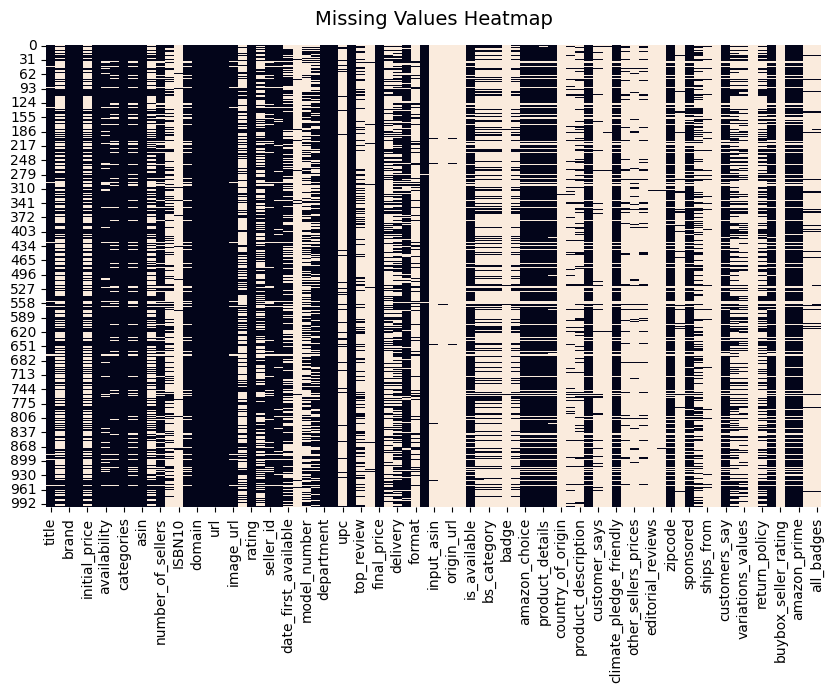

In [7]:
plot_missing_values(df)

### Analysis:

The heatmap shows that the dataset still contains missing values across multiple features.

* Columns such as `title`, `brand`, `categories`, `asin`, `department`, and `final_price` are relatively complete with only a small number of missing values.
* Several columns contain a large amount of missing data, including `initial_price`, `availability`, `top_review`, `seller_id`, `product_description`, `editorial_reviews`, `customers_say`, and `buybox_seller_rating`.
* The `discount` column has a very high missing-value ratio because many products do not provide discount information.
* Some metadata-related attributes such as `model_number`, `ships_from`, `country_of_origin`, and `variations_values` also contain many null values, which is common in e-commerce datasets where sellers may provide incomplete product details.

These missing values were handled during the preprocessing stage by:

* Filling missing text values with default placeholders or empty strings.
* Filling missing numerical values using mean or median values.
* Converting data types appropriately before building the recommendation system.

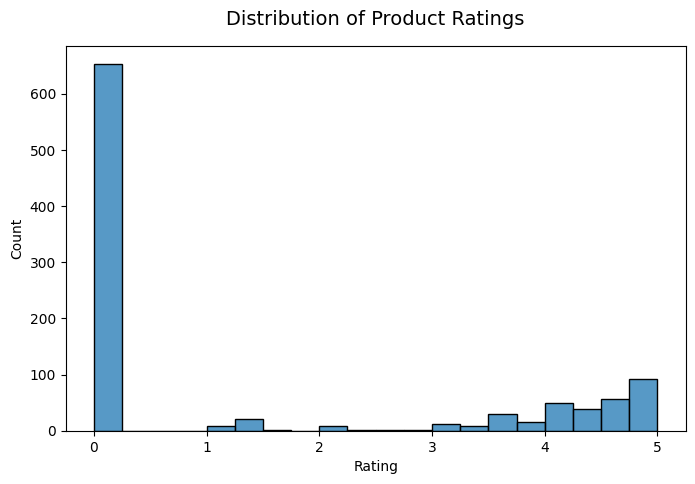

In [8]:
plot_rating_distribution(df)

### Analysis:

The rating distribution shows that the dataset is highly imbalanced toward very low and very high rating values.

* A large number of products have ratings close to `0`, which may indicate missing ratings, unrated products, or noisy rating data.
* Aside from the zero-rating group, most products are concentrated between ratings `4.0` and `5.0`, showing that many products receive positive customer feedback.
* Very few products fall within the middle rating range (`2.0` to `3.5`), resulting in a skewed distribution.
* The distribution suggests that highly rated products dominate the dataset, which is common in e-commerce platforms where users are more likely to rate products positively.

This imbalance may affect recommendation performance, especially for collaborative filtering models, because products with very few ratings may not provide enough interaction information for learning user preferences effectively.

The rating feature is still an important attribute for recommendation systems, particularly for popularity-based recommendation and collaborative filtering approaches.

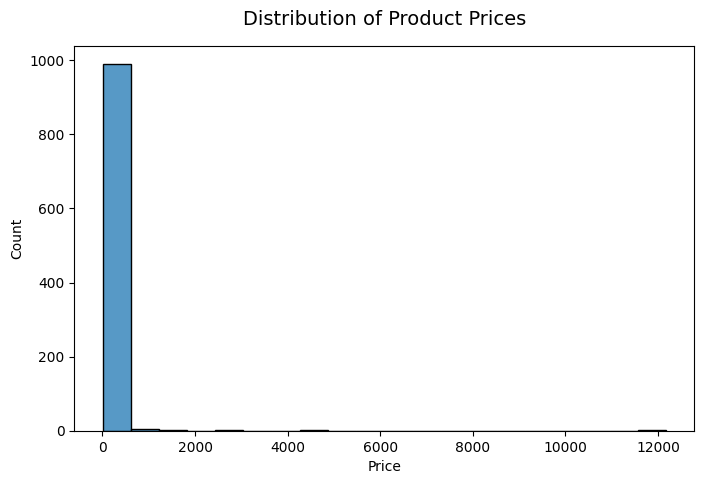

In [9]:
plot_price_distribution(df)

### Analysis:

The product price distribution shows a highly right-skewed distribution.

* Most products are concentrated in the lower price range, indicating that the majority of items are relatively inexpensive.
* A small number of products have extremely high prices, creating several visible outliers on the far right side of the distribution.
* The dataset contains a wide price range, from low-cost products to premium or luxury-priced items.
* The large concentration of low-price products is common in e-commerce datasets, where affordable products typically dominate online marketplaces.

The presence of extreme outliers may affect recommendation models if price is used directly as a feature. Therefore, price normalization or scaling techniques may be helpful during feature engineering.

Overall, the chart suggests that product prices vary significantly across different categories and brands within the dataset.

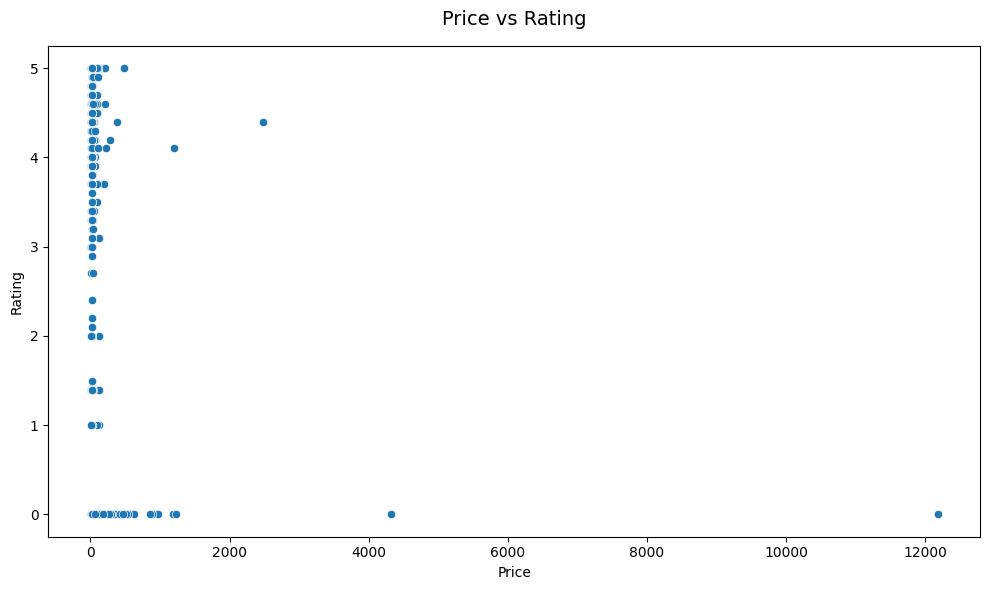

In [10]:
plot_price_vs_rating(df)

### Analysis:

The scatter plot shows that the relationship between product price and rating is relatively weak.

* Most products are concentrated in the low-price range, while their ratings vary from `0` to `5`.
* Products with high ratings appear across different price levels, indicating that expensive products are not necessarily rated better than cheaper ones.
* Several products with ratings close to `0` are visible across multiple price ranges, which may represent unrated products or missing rating information.
* A few extreme price outliers can be observed, including products priced above `4000` and `12000`, but these products still have low or zero ratings.
* The data points are widely scattered and do not form a clear linear trend between price and rating.

This suggests that product price alone is not a strong indicator of customer satisfaction or product quality in the dataset.

For recommendation systems, relying only on price may not produce effective recommendations. Combining price with other features such as product descriptions, categories, brands, and user interactions can improve recommendation quality.

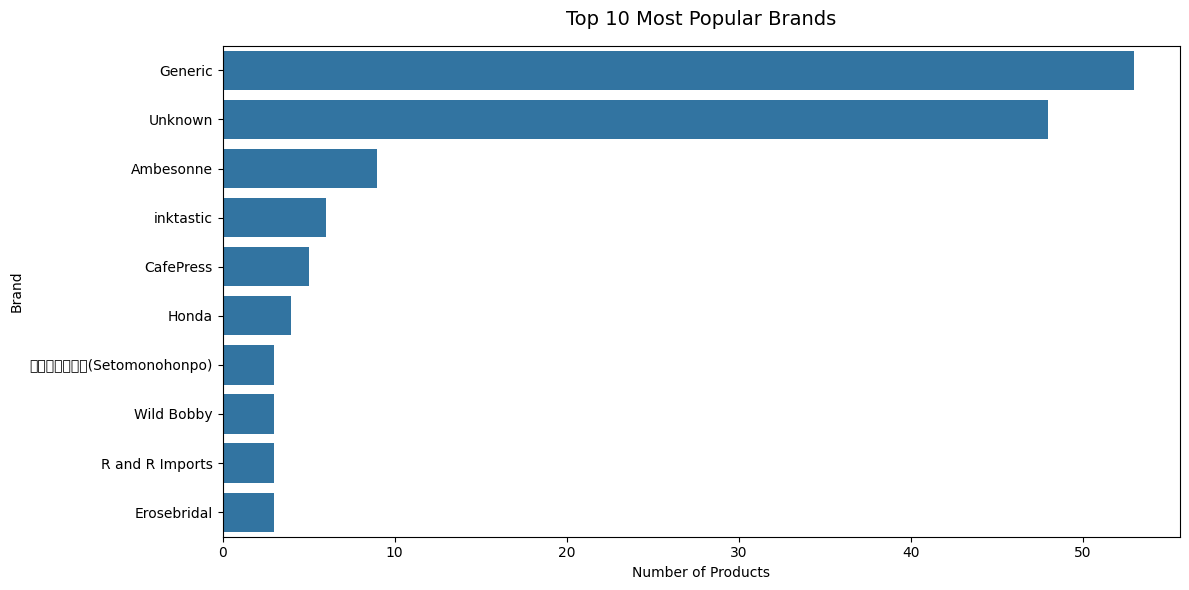

In [11]:
plot_top_brands(df)

### Analysis:

The chart illustrates the distribution of product counts across the top 10 most popular brands in the dataset.

* The brands `Generic` and `Unknown` dominate the dataset with significantly higher product counts compared to all other brands.
* The large number of `Generic` and `Unknown` entries suggests that many products either do not specify a clear brand name or use generic branding.
* Brands such as `Ambesonne`, `inktastic`, `CafePress`, and `Honda` also appear frequently, although their product counts are much lower than the top two brands.
* The remaining brands have relatively small product counts, indicating an uneven brand distribution within the dataset.
* Some brand names may represent marketplace sellers or niche manufacturers rather than globally recognized brands.

This imbalance may influence recommendation performance because frequently occurring brands can dominate content-based similarity calculations.

Brand information can still be a valuable feature in recommendation systems, especially for users who prefer familiar or trusted brands.

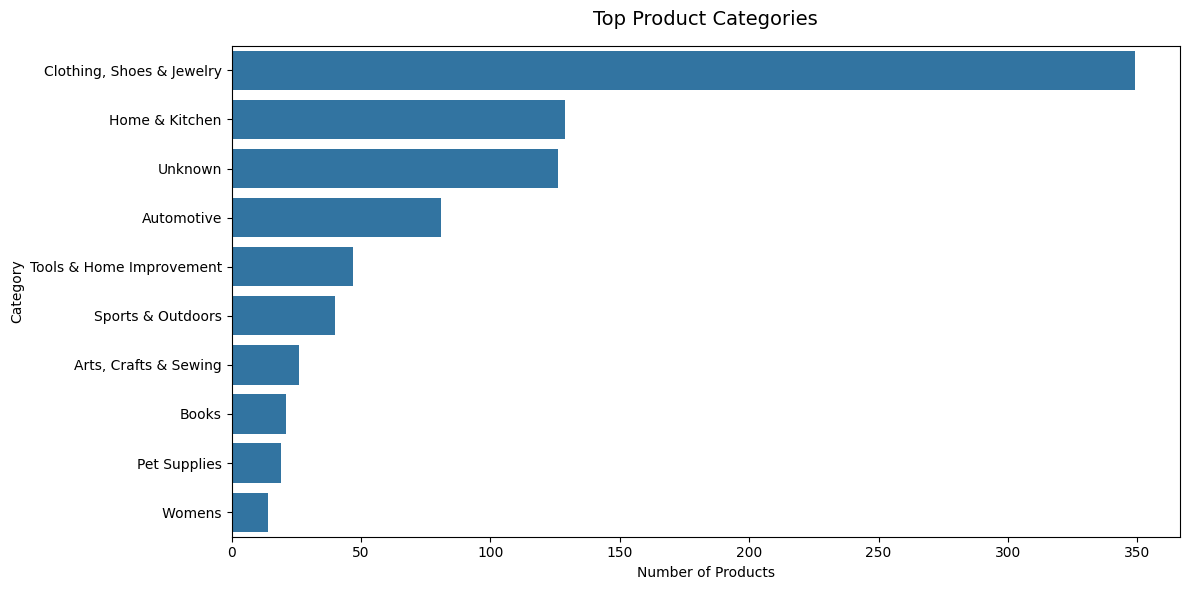

In [12]:
plot_top_departments(df)

### Analysis:

The chart shows the distribution of products across the top product categories (`department`) in the dataset.

* The category `Clothing, Shoes & Jewelry` contains the largest number of products by a significant margin, indicating that fashion-related products dominate the dataset.
* Categories such as `Home & Kitchen` and `Unknown` also contain a relatively high number of products, suggesting that these are common product groups in the marketplace.
* `Automotive`, `Tools & Home Improvement`, and `Sports & Outdoors` have moderate product counts compared to the leading categories.
* Categories including `Books`, `Pet Supplies`, and `Womens` contain fewer products, resulting in an imbalanced category distribution.
* The presence of the `Unknown` category indicates that some products may have incomplete or missing category information.

This imbalance reflects real-world e-commerce platforms, where some departments naturally contain far more products than others.

Category information is an important feature for recommendation systems because it helps group similar products and improve recommendation relevance based on user interests and browsing behavior.

In [14]:
from src.eda import (
    get_popular_products_by_department
)

In [15]:
get_popular_products_by_department(df)

,asin,root_bs_rank,department
556,B06Y26MCTT,0.0,Boys
150,B081ZNHXZL,0.0,Boys
297,B0D3GHGXNY,83.0,Electronics
122,B0DZC2F18S,1060.0,Electronics
939,B07GJJJQZS,3450.0,Electronics
...,...,...,...
311,B0CYQD8HS4,3431192.0,Kindle Store
750,B01LB2UGHC,5304085.0,‏ ‎ Mens
913,B09ZPLY99T,5502826.0,‏ ‎ womens
326,B01CIPN86C,6430828.0,‏ ‎ Baby-boys


### Analysis:

The table displays products with the best `root_bs_rank` values across different departments.

* Products are sorted by `root_bs_rank` in ascending order, where smaller values indicate better sales performance or popularity.
* Categories such as `Electronics`, `Boys`, and `Clothing, Shoes & Jewelry` appear multiple times, suggesting that these departments contain highly popular products.
* Some products have extremely large `root_bs_rank` values, indicating lower sales performance compared to top-ranked products.
* The dataset contains a wide variation in popularity rankings across different product categories.

This information can be useful for popularity-based recommendation systems because products with better bestseller rankings are more likely to attract user interest and engagement.

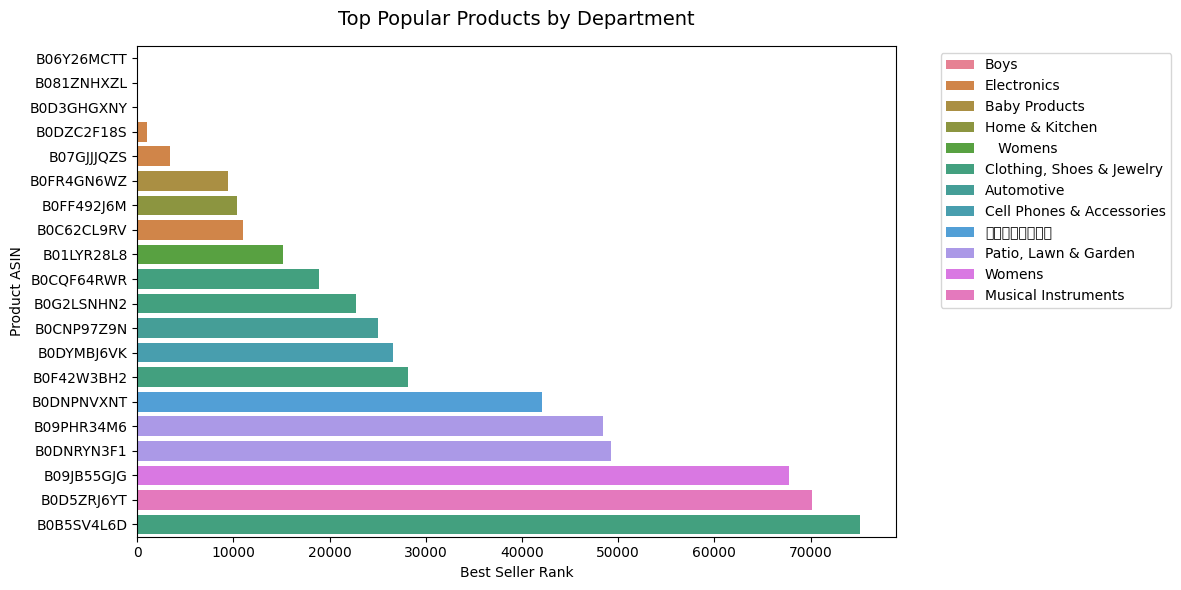

In [18]:
plot_popular_products_by_department(df)

### Analysis:

The chart visualizes products with the best `root_bs_rank` values across different departments.

* Products are ranked based on `Best Seller Rank`, where lower values indicate higher popularity or better sales performance.
* Categories such as `Clothing, Shoes & Jewelry`, `Patio, Lawn & Garden`, and `Womens` contain products with relatively high bestseller rankings compared to other departments.
* Departments including `Electronics`, `Home & Kitchen`, and `Automotive` also appear frequently, indicating that these categories contain several popular products.
* The distribution of bestseller rankings varies significantly across departments, showing differences in product popularity among categories.
* Some products have extremely large `Best Seller Rank` values, which may indicate lower market popularity compared to top-ranked products.

This information is useful for popularity-based recommendation systems because bestseller rankings can help identify trending or highly demanded products for recommendation, especially for new users with limited interaction history.

### Hiển thị danh sách các tên cột trong Data Frame df_new

In [19]:
# ==============================
# FEATURE ENGINEERING
# ==============================

df = create_combined_features(df)

df[
    ["title", "combined_features"]
].head()

,title,combined_features
0,Movie Posters A Bout De Souffle Room Decor Pos...,Movie Posters A Bout De Souffle Room Decor Pos...
1,NaN,Unknown Unknown Unknown
2,Tiny Twinkle Splat Mat for Under High Chair or...,Tiny Twinkle Splat Mat for Under High Chair or...
3,Prince On Board Vinyl Decal Car Window Bumper ...,Prince On Board Vinyl Decal Car Window Bumper ...
4,McFarlane Toys Movie Maniacs - Fallout The Gho...,McFarlane Toys Movie Maniacs - Fallout The Gho...


### Analysis:

Important textual attributes such as product title, brand, description, categories, and department are combined into a single feature called `combined_features`.

Combining multiple text attributes allows the content-based recommendation system to capture richer product information when calculating similarity between products.

This approach helps the recommendation model better understand product characteristics and improves the quality of content similarity calculations using TF-IDF and cosine similarity.

Additionally, rows containing insufficient or extremely limited textual information were removed during preprocessing to reduce noise and improve recommendation performance.

In [20]:
# ==============================
# TF-IDF VECTORIZATION
# ==============================

tfidf_matrix, cosine_sim = (
    create_similarity_matrix(df)
)

print("TF-IDF Matrix Shape:")
print(tfidf_matrix.shape)

TF-IDF Matrix Shape:
(998, 13990)


### Analysis:

TF-IDF Vectorization is used to transform textual data into numerical vector representations.

The result is a sparse matrix where:

* each row represents a product
* each column represents a textual feature (term)

The matrix shape `(998, 13990)` indicates that:

* the dataset contains 998 products
* approximately 13,990 unique textual features were extracted from the product information.

In [21]:
# Convert sparse matrix to dataframe (preview)

tfidf_df = pd.DataFrame.sparse.from_spmatrix(
    tfidf_matrix
)

tfidf_df.head()

,0,1,2,3,4,5,6,7,8,9,...,13980,13981,13982,13983,13984,13985,13986,13987,13988,13989
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Analysis:

The TF-IDF matrix is stored as a sparse matrix where most values are `0`, because each product contains only a small subset of all possible textual features.

Using a sparse matrix helps reduce memory usage and improves computational efficiency when processing high-dimensional textual data.

In [22]:
# ==============================
# COSINE SIMILARITY
# ==============================

print("Cosine Similarity Shape:")
print(cosine_sim.shape)

Cosine Similarity Shape:
(998, 998)


### Analysis:

Cosine Similarity is used to measure the similarity between products based on their TF-IDF vectors.

The similarity matrix shape `(998, 998)` indicates that similarity scores are calculated between every pair of products in the dataset.

# Popularity-Based Recommendation System

In [23]:
popular_products = get_popular_products(df)

popular_products

,title,brand,rating,department
149,Aleola Case Compatible with Huawei Freebuds 3 ...,Aleola,5.0,Boys
554,superfit Boy's Slippers Hi-Top Trainers,superfit,5.0,Boys
181,"Zoom H1essential Stereo Handy Recorder, H1 Ess...",SonicSound Technologies,5.0,Musical Instruments
891,"Volleyball Cake Toppers for Girls, 25Pcs Glitt...",partiqla,5.0,Toys & Games
925,"Cactus Gifts for Women, Unique Gifts Includes ...",fcaylo,5.0,Home & Kitchen
645,KarParts360 For Chevy Blazer Signal Light Asse...,KarParts360,5.0,"Lights, Bulbs & Indicators"
91,BERISSA Cordless Dual Roller Shades with Casse...,BERISSA,5.0,Home & Kitchen
882,115V Rotom Fan Motor - Model R5401 with 115V a...,Ancaster Food Equipment,5.0,Appliances
762,Unfinished Wood Tombstone Shape Craft up to 46...,24 Hour Crafts,5.0,"Arts, Crafts & Sewing"
709,Neighborhood Cats Handler/Den - White/Clear Door,Tomahawk Live Trap,5.0,Sports & Outdoors


### Analysis:

The popularity-based recommendation system suggests products based on product popularity and ratings.

Products are ranked by:

* descending rating values
* ascending bestseller rank values

This approach is suitable for:

* new users
* users without interaction history
* cold-start scenarios

However, the system does not personalize recommendations based on individual user preferences, so the level of personalization is still limited.

# Content-Based Recommendation System

In [24]:
# ==============================
# CREATE TITLE INDEX MAPPING
# ==============================

indices = create_indices(df)

indices.head()

title
Movie Posters A Bout De Souffle Room Decor Posters (3) Wall Art Paintings Canvas Wall Decor Home Decor Living Room Decor Aesthetic Prints 20x30inch(50x75cm) Frame-style    0
NaN                                                                                                                                                                         1
Tiny Twinkle Splat Mat for Under High Chair or Table | 44" x 44" Waterproof & Mess-Proof High Chair Mat for Baby, Machine Washable for Mealtime or Art(Black Checkers)      2
Prince On Board Vinyl Decal Car Window Bumper Truck Wall Decor Sticker                                                                                                      3
McFarlane Toys Movie Maniacs - Fallout The Ghoul 6in Posed Figure                                                                                                           4
dtype: int64

### Analysis:

Title-index mapping is used to connect product titles with their corresponding positions in the dataset.

This mapping helps the recommendation system to:

* quickly identify product indices
* retrieve the corresponding similarity vectors
* improve recommendation search efficiency

Each product title is associated with a unique index in the cosine similarity matrix.

In [25]:
recommendations = recommend_products(
    keyword="iPhone",
    df=df,
    cosine_sim=cosine_sim
)

recommendations

SEARCH KEYWORD: iPhone
MATCHED PRODUCT:
kalibri Smartphone S-Sticker - Mobile sticker made out of fabric - e.g. compatible with iPhone 6 / SE / 5, Samsung Galaxy S6, Huawei P8 Lite, Sony Xperia etc.


,title,brand,department,rating
342,Large 9x12 Sticker - Sticker Teach A Man To Fi...,Happy Stickers,Automotive,0.0
1,NaN,Unknown,Unknown,0.0
12,NaN,Unknown,Unknown,0.0
44,NaN,Unknown,Unknown,0.0
90,NaN,Unknown,Unknown,0.0
133,NaN,Unknown,Unknown,0.0
140,NaN,Unknown,Unknown,0.0
288,NaN,Unknown,Unknown,0.0
295,NaN,Unknown,Unknown,0.0
331,NaN,Unknown,Unknown,0.0


### Analysis:

When the user enters the keyword `"iPhone"`, the system searches for the first matching product in the dataset and uses cosine similarity to find products with similar content.

The recommendation results include:

* product title
* brand
* department
* rating

The recommended products are mostly related to phone accessories, stickers, or products with similar textual content to the keyword `"iPhone"`, showing that the system successfully captures product similarity based on textual information.

# Collaborative Filtering Recommendation System

In [26]:
# ==============================
# SIMULATE USER RATINGS
# ==============================

interactions_df = simulate_user_interactions(
    df,
    num_users=100,
    interactions_per_user=20
)

interactions_df.head()

,user_id,title,rating
0,1,Scarf for Women Lightweight Paisley Floral Fas...,4.5
1,1,Animal with Extra-Long Arms，Give The Gift,0.0
2,1,Comfortable Dog Walking Leash Retractable Stro...,0.0
3,1,Pair Set 2 Rear Stabilizer Bar Links for Saab ...,0.0
4,1,Heyiarbeit 100pcs Snap Bushing Grommets 5/8 In...,4.1


User interaction data is simulated by allowing each user to randomly rate a number of products from the dataset.

Each interaction contains:

* `user_id`
* product title
* rating

This step creates input data for collaborative filtering in cases where the original dataset does not contain real user interaction history.


In [27]:
# ==============================
# USER-ITEM MATRIX
# ==============================

user_item_matrix = create_user_item_matrix(
    interactions_df
)

user_item_matrix.head()

title,0-14mm Trucks Puncher Model Tool Metal Reamer Body Shell Aircraft Portable For Car Hole Opener Expanding Drill,1 Pair Nonslip Foam Sponge Bike Motorcycle Handle Cover,1 pc/Set Engine Motor Mount C2D19868 C2D19868 Compatible with XF/XJ CAIJUN-AUTO,1-Head Industrial Pendant Light with Plug Adjustable 16.4ft Hanging Cord Dimmer Switch Farmhouse Cage Glass Hanging Lighting Fixture Chandelier Hight Low Ceiling Lamp for Kitchen Island Entryway Foyer,1.95 Carat 14K White Gold Baguette Round GIA Certified Round Cut Diamond Engagement Ring (1.7 Ct D Color SI2 Clarity Center Stone),"1/2"" 12FT Tinned Copper Braid Cable, Flat Braided Ground Strap Sleeving, Expandable High Strength Conductivity for Industrial Applications Wire Protection",12 Pcs Baptism Design Keychain Bottle Opener Party Favors for Baby Boys and Girls/Bautizo Recuerdos/Gift for Guest/Christening Favors,14K Yellow Gold & Rhodium Emerald & Diamond Dolphin Post Earrings,"1Pcs Master Cylinder, Brake Master Cylinder Replacement Fits Verna 2004 2005 Fits Accent 2000 2004 2005 2001 2002 2003",1Pcs Over and Under Voltage Protective Device Automatic Self-Recovery Reconnect Protection Relay 32/40/50/60A AC 220V (Size : 80A) (Size : 50A),...,sdbrld Womens Lolita Gothic Dress Vintage Bow Ruffle Dress Plus Size Steampunk Dress Long Sleeve Renaissance Dress Cosplay,"senya 2 Piece Bath Towel Set, Cotton Bath Towels for Bathroom, 1 Extra Large Bath Towels and 1 Washcloths, Pink Halloween Bathroom Shower Towels(236na6j)",senya Women Winter Warm Hoodie Hat Scarf Gloves Pocket Warm Hat Colorful Peacock Petal Long Scarf Wraps(227be1h),siilsaa Wedge Sandals for Women Zipper Platform Sandals T Strap Open Toe Casual Summer Beach Sandals Retro Roman Shoes,stylesilove Infant Toddler British Flag Jean Print Baby Boy Romper,superfit Boy's Slippers Hi-Top Trainers,"uxcell M6 Wing Nuts, Stainless Steel 201 Fasteners Parts Hurrican Screws Hand Twist Tighten Ear Butterfly Nut, 10pcs",vidaXL Modern Black Oak Bathroom Cabinet with 6 Shelves and Stylish Design | Engineered Wood Storage for Indoor Use Versatile Free Standing Solution Home Shelf Furniture Solutions Organizer,wild custom apparel Kevin Buzz Your Girlfriend Woof Boy Face Ugly Christmas Crewneck Sweatshirt,ゼロ
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The user-item matrix represents the relationship between users and products based on rating values.

In the matrix:

* each row represents a user
* each column represents a product
* each cell value represents the rating given by the user to the product

This matrix serves as the main input for the collaborative filtering model using K-Nearest Neighbors (KNN).

In [28]:
# ==============================
# TRAIN KNN MODEL
# ==============================

model_knn = train_knn_model(
    user_item_matrix
)

model_knn

,n_neighbors,5
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'cosine'
,p,2
,metric_params,None
,n_jobs,None


The KNN model is trained on the user-item matrix to identify users with similar rating behaviors.

Cosine similarity is used to measure the similarity between users based on their rating vectors.

In [29]:
# ==============================
# FIND SIMILAR USERS
# ==============================

find_similar_users(
    model_knn,
    user_item_matrix,
    query_index=10,
    n_neighbors=5
)

SIMILAR USERS
User: 10, Distance: 0.0000
User: 42, Distance: 0.7415
User: 66, Distance: 0.8111
User: 36, Distance: 0.8132
User: 50, Distance: 0.8261


(array([[0.        , 0.74146989, 0.81107248, 0.8132014 , 0.82606798]]),
 array([[10, 42, 66, 36, 50]], dtype=int64))

The result shows that the system successfully identifies users with similar rating behaviors.

Smaller cosine distance values indicate higher similarity between users.

This information can be used in collaborative filtering to recommend products that similar users have rated highly.


# Hybrid Recommendation System

In [30]:
# ==============================
# HYBRID RECOMMENDATION SYSTEM
# FOR NEW USERS
# ==============================

hybrid_recommendation(
    user_type="new",
    df=df
)

POPULAR PRODUCTS FOR NEW USERS


,title,brand,rating,department
149,Aleola Case Compatible with Huawei Freebuds 3 ...,Aleola,5.0,Boys
554,superfit Boy's Slippers Hi-Top Trainers,superfit,5.0,Boys
181,"Zoom H1essential Stereo Handy Recorder, H1 Ess...",SonicSound Technologies,5.0,Musical Instruments
891,"Volleyball Cake Toppers for Girls, 25Pcs Glitt...",partiqla,5.0,Toys & Games
925,"Cactus Gifts for Women, Unique Gifts Includes ...",fcaylo,5.0,Home & Kitchen
645,KarParts360 For Chevy Blazer Signal Light Asse...,KarParts360,5.0,"Lights, Bulbs & Indicators"
91,BERISSA Cordless Dual Roller Shades with Casse...,BERISSA,5.0,Home & Kitchen
882,115V Rotom Fan Motor - Model R5401 with 115V a...,Ancaster Food Equipment,5.0,Appliances
762,Unfinished Wood Tombstone Shape Craft up to 46...,24 Hour Crafts,5.0,"Arts, Crafts & Sewing"
709,Neighborhood Cats Handler/Den - White/Clear Door,Tomahawk Live Trap,5.0,Sports & Outdoors


For new users without interaction history, the system uses popularity-based recommendation to suggest highly popular and highly rated products.

In [35]:
# ==============================
# HYBRID RECOMMENDATION SYSTEM
# FOR SEARCH USERS
# ==============================

hybrid_recommendation(
    user_type="search",
    keyword="Samsung",
    df=df,
    cosine_sim=cosine_sim
)

CONTENT-BASED RECOMMENDATIONS
SEARCH KEYWORD: Samsung
MATCHED PRODUCT:
DistinctInk Clear Shockproof Hybrid Case for Samsung Galaxy Note 20 Ultra (6.9" Screen) - TPU Bumper, Acrylic Back, Tempered Glass Screen Protector - Seattle Skyline Night - Show Your Love of Seattle


,title,brand,department,rating
637,Compatible with Samsung Galaxy S24 Cute Clear ...,Mamarmot,Cell Phones & Accessories,3.0
937,GFJNFG for 2015-2021 2022 2023 Dodge Challenge...,Generic,Electronics,0.0
121,Silicone Case for Panasonic LUMIX ZS99 with Re...,Tedubax,Electronics,4.7
961,"KANGYA Compatible with Moto E Phone Case, Moto...",BENTOBEN,Unknown,4.4
226,"for Google Pixel 9 Pro Case, Floral Pattern De...",LEECG,Cell Phones & Accessories,4.5
350,For Samsung Illusion / Galaxy Proclaim i110 (V...,Zizo,Unknown,3.6
149,Aleola Case Compatible with Huawei Freebuds 3 ...,Aleola,Boys,5.0
933,2 Pack Steel Metal USB Charging Cable Data Tra...,CCDZ,Cell Phones & Accessories,3.3
532,Duluth Pack L-510-55-BLK Leather Shotgun Case ...,Duluth Pack,"Clothing, Shoes & Jewelry",0.0
94,"KNOMO Harpsden 15"" Waterproof Laptop Backpack ...",KNOMO,Electronics,3.9


Khi người dùng tìm kiếm theo từ khóa, hệ thống sử dụng content-based recommendation để tìm các sản phẩm có nội dung tương tự dựa trên cosine similarity.

In [36]:
# ==============================
# HYBRID RECOMMENDATION SYSTEM
# FOR EXISTING USERS
# ==============================

hybrid_recommendation(
    user_type="existing",
    df=df
)

COLLABORATIVE FILTERING RECOMMENDATIONS


'Recommendations based on user similarity.'

Đối với người dùng đã có lịch sử tương tác, hệ thống có thể sử dụng collaborative filtering để đề xuất sản phẩm dựa trên hành vi của các người dùng tương tự.

# Model Evaluation

In [37]:
evaluate_popularity(df)

POPULARITY-BASED EVALUATION
Average Rating@10: 5.00


,title,brand,rating,department
149,Aleola Case Compatible with Huawei Freebuds 3 ...,Aleola,5.0,Boys
554,superfit Boy's Slippers Hi-Top Trainers,superfit,5.0,Boys
181,"Zoom H1essential Stereo Handy Recorder, H1 Ess...",SonicSound Technologies,5.0,Musical Instruments
891,"Volleyball Cake Toppers for Girls, 25Pcs Glitt...",partiqla,5.0,Toys & Games
925,"Cactus Gifts for Women, Unique Gifts Includes ...",fcaylo,5.0,Home & Kitchen
645,KarParts360 For Chevy Blazer Signal Light Asse...,KarParts360,5.0,"Lights, Bulbs & Indicators"
91,BERISSA Cordless Dual Roller Shades with Casse...,BERISSA,5.0,Home & Kitchen
882,115V Rotom Fan Motor - Model R5401 with 115V a...,Ancaster Food Equipment,5.0,Appliances
762,Unfinished Wood Tombstone Shape Craft up to 46...,24 Hour Crafts,5.0,"Arts, Crafts & Sewing"
709,Neighborhood Cats Handler/Den - White/Clear Door,Tomahawk Live Trap,5.0,Sports & Outdoors


In [38]:
# ==============================
# CONTENT-BASED EVALUATION
# ==============================

precision_at_k(
    keyword="Samsung",
    df=df,
    cosine_sim=cosine_sim,
    k=10
)

SEARCH KEYWORD: Samsung
MATCHED PRODUCT:
DistinctInk Clear Shockproof Hybrid Case for Samsung Galaxy Note 20 Ultra (6.9" Screen) - TPU Bumper, Acrylic Back, Tempered Glass Screen Protector - Seattle Skyline Night - Show Your Love of Seattle
CONTENT-BASED EVALUATION
Precision@10: 0.30


,title,brand,department,rating
637,Compatible with Samsung Galaxy S24 Cute Clear ...,Mamarmot,Cell Phones & Accessories,3.0
937,GFJNFG for 2015-2021 2022 2023 Dodge Challenge...,Generic,Electronics,0.0
121,Silicone Case for Panasonic LUMIX ZS99 with Re...,Tedubax,Electronics,4.7
961,"KANGYA Compatible with Moto E Phone Case, Moto...",BENTOBEN,Unknown,4.4
226,"for Google Pixel 9 Pro Case, Floral Pattern De...",LEECG,Cell Phones & Accessories,4.5
350,For Samsung Illusion / Galaxy Proclaim i110 (V...,Zizo,Unknown,3.6
149,Aleola Case Compatible with Huawei Freebuds 3 ...,Aleola,Boys,5.0
933,2 Pack Steel Metal USB Charging Cable Data Tra...,CCDZ,Cell Phones & Accessories,3.3
532,Duluth Pack L-510-55-BLK Leather Shotgun Case ...,Duluth Pack,"Clothing, Shoes & Jewelry",0.0
94,"KNOMO Harpsden 15"" Waterproof Laptop Backpack ...",KNOMO,Electronics,3.9


In [39]:
# ==============================
# COLLABORATIVE FILTERING
# EVALUATION
# ==============================

evaluate_collaborative(
    interactions_df
)

COLLABORATIVE FILTERING EVALUATION
RMSE: 2.1196
MAE : 1.9116


(2.1195904330648205, 1.9116327269296094)

## Model Evaluation Summary

* The popularity-based recommendation model achieved an `Average Rating@10` of `5.00`, indicating that the system successfully recommends highly rated and popular products.

* The content-based recommendation model achieved a `Precision@10` of `0.30`, showing that several recommended products are relevant to the search keyword based on textual similarity using TF-IDF and cosine similarity.

* The collaborative filtering model was evaluated using `RMSE` and `MAE`:

  * `RMSE = 2.1196`
  * `MAE = 1.9116`

  These results indicate that the collaborative filtering model can predict user ratings at an acceptable level on the simulated interaction dataset.

Each recommendation approach has different strengths:

* Popularity-Based Recommendation works well for cold-start users.
* Content-Based Recommendation recommends products with similar textual content.
* Collaborative Filtering captures user preference patterns through user interactions.

The hybrid recommendation system combines these approaches to improve overall recommendation quality and flexibility.


## References:
- Priyanshu Madan (2019), Building an E-Commerce Product Recommendation Engine in Python.
  https://medium.com/priyanshumadan/building-an-e-commerce-product-recommendation-engine-in-python-affb004e47c9
- Amar Shaw (2020), Product Recommendation System for e-commerce
  https://www.kaggle.com/code/shawamar/product-recommendation-system-for-e-commerce
  